In [1]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Dropout, SimpleRNN, LSTM, GRU, BatchNormalization, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error

c:\Users\USER\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\USER\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\USER\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in t

In [ ]:
from keras.datasets import fashion_mnist
(x_data, y_data), (val_x, val_y) = fashion_mnist.load_data()

In [3]:
x_data.shape, y_data.shape, val_x.shape, val_y.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
tr_x, tt_x, tr_y, tt_y = train_test_split(x_data, y_data, test_size=.2, stratify=y_data)
tr_x.shape, tt_x.shape,tr_y.shape, tt_y.shape

((42000, 28, 28), (18000, 28, 28), (42000,), (18000,))

In [ ]:
tr_x.shape, val_x.shape, tt_x.shape,    tr_y.shape, val_y.shape, tt_y.shape

((42000, 28, 28),
 (10000, 28, 28),
 (18000, 28, 28),
 (42000,),
 (10000,),
 (18000,))

In [6]:
np.unique(tt_y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [16]:
m = Sequential()
m.add(Input(shape=(tr_x.shape[1:])))
m.add(Flatten())
m.add(Dense(100, activation='sigmoid'))
m.add(Dense(100, activation='sigmoid'))
m.add(Dense(10, activation='sigmoid'))
m.summary()
m.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['acc'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
es = EarlyStopping(patience=3, restore_best_weights=True, verbose=1)
ck = ModelCheckpoint('bset_m.keras', save_best_only=True, verbose=1)

In [18]:
m.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=100, callbacks=[es, ck])

Epoch 1/100
1303/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.4939 - loss: 1.8672
Epoch 1: val_loss improved from None to 1.09260, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.6004 - loss: 1.5390 - val_acc: 0.6712 - val_loss: 1.0926
Epoch 2/100
1306/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7008 - loss: 0.9826
Epoch 2: val_loss improved from 1.09260 to 0.81726, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.7159 - loss: 0.9137 - val_acc: 0.7335 - val_loss: 0.8173
Epoch 3/100
1298/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7451 - loss: 0.7742
Epoch 3: val_loss improved from 0.81726 to 0.71495, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.7531 - loss: 0.7509 - val_acc: 0.7488 - val_loss: 0.7150
Epoch 4/100
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7658 - loss: 0.7008
Epoch 4: val_loss improved from 0.71495 to 0.68270, saving model to bset_m.keras
1313/1313 ━━━━━━

In [ ]:
es = EarlyStopping(patience=3, restore_best_weights=False, verbose=1)
ck = ModelCheckpoint('bset_m.keras', save_best_only=True, verbose=1)

In [19]:
l_m = load_model('bset_m.keras')
l_m.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,612 (350.05 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
print(m.evaluate(tr_x, tr_y))

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7852 - loss: 0.5941


[0.5941268801689148, 0.7852380871772766]

In [ ]:
print(l_m.evaluate(tr_x, tr_y))

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7852 - loss: 0.5941


[0.5941268801689148, 0.7852380871772766]

In [ ]:
# 가중치를 완벽하게 복사함

스케일링을 왜 하나?
- 각 특성의 중요도를 맞추기 위해
- 학습 속도 향상 및 안정성 확보
- 거리 기반의 알고리즘 성능 향상

일반적으로 전처리는 학습 데이터셋 기준으로 진행됨

In [25]:
np.unique(tr_x/255)[:100]

array([0.        , 0.00392157, 0.00784314, 0.01176471, 0.01568627,
       0.01960784, 0.02352941, 0.02745098, 0.03137255, 0.03529412,
       0.03921569, 0.04313725, 0.04705882, 0.05098039, 0.05490196,
       0.05882353, 0.0627451 , 0.06666667, 0.07058824, 0.0745098 ,
       0.07843137, 0.08235294, 0.08627451, 0.09019608, 0.09411765,
       0.09803922, 0.10196078, 0.10588235, 0.10980392, 0.11372549,
       0.11764706, 0.12156863, 0.1254902 , 0.12941176, 0.13333333,
       0.1372549 , 0.14117647, 0.14509804, 0.14901961, 0.15294118,
       0.15686275, 0.16078431, 0.16470588, 0.16862745, 0.17254902,
       0.17647059, 0.18039216, 0.18431373, 0.18823529, 0.19215686,
       0.19607843, 0.2       , 0.20392157, 0.20784314, 0.21176471,
       0.21568627, 0.21960784, 0.22352941, 0.22745098, 0.23137255,
       0.23529412, 0.23921569, 0.24313725, 0.24705882, 0.25098039,
       0.25490196, 0.25882353, 0.2627451 , 0.26666667, 0.27058824,
       0.2745098 , 0.27843137, 0.28235294, 0.28627451, 0.29019

In [26]:
e_tr_x = tr_x/255
e_tt_x = tt_x/255
e_val_x = val_x/255

In [55]:
m = Sequential()
m.add(Input(shape=(tr_x.shape[1:])))
m.add(Flatten())
m.add(Dense(100, activation='sigmoid'))
m.add(Dense(100, activation='sigmoid'))
m.add(Dense(10, activation='sigmoid'))
m.summary()
m.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['acc'])

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(patience=5, restore_best_weights=False, verbose=1)
ck = ModelCheckpoint('bset_m.keras', save_best_only=True, verbose=1)

In [29]:
m.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=100, callbacks=[es, ck])

Epoch 1/100
1307/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.4661 - loss: 1.9170
Epoch 1: val_loss improved from None to 1.09305, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.5886 - loss: 1.5724 - val_acc: 0.6808 - val_loss: 1.0931
Epoch 2/100
1299/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7022 - loss: 0.9821
Epoch 2: val_loss improved from 1.09305 to 0.80694, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.7165 - loss: 0.9088 - val_acc: 0.7355 - val_loss: 0.8069
Epoch 3/100
1292/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7506 - loss: 0.7645
Epoch 3: val_loss improved from 0.80694 to 0.72727, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.7524 - loss: 0.7493 - val_acc: 0.7511 - val_loss: 0.7273
Epoch 4/100
1306/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7655 - loss: 0.6944
Epoch 4: val_loss improved from 0.72727 to 0.68685, saving model to bset_m.keras
1313/1313 ━━━━━━

In [56]:
sgd = SGD(0.0001)

In [57]:
m = Sequential()
m.add(Input(shape=tr_x.shape[1:]))
m.add(Flatten())
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(50, activation='sigmoid'))
m.add(Dense(10, activation='sigmoid'))
m.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,060 (215.08 KB)

 Trainable params: 55,060 (215.08 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
m.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['acc'])

In [59]:
es = EarlyStopping(patience=10, restore_best_weights=False, verbose=1)
ck = ModelCheckpoint('bset_m.keras', save_best_only=True, verbose=1)

아래는 단순히 모델만 바꾼거

In [60]:
hy = m.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=100, callbacks=[es, ck])

Epoch 1/100
1280/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.0968 - loss: 2.5599
Epoch 1: val_loss improved from None to 2.50359, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.1000 - loss: 2.5419 - val_acc: 0.1000 - val_loss: 2.5036
Epoch 2/100
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.0984 - loss: 2.4896
Epoch 2: val_loss improved from 2.50359 to 2.44458, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.1000 - loss: 2.4726 - val_acc: 0.1000 - val_loss: 2.4446
Epoch 3/100
1288/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.1019 - loss: 2.4296
Epoch 3: val_loss improved from 2.44458 to 2.40195, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.1000 - loss: 2.4221 - val_acc: 0.1000 - val_loss: 2.4020
Epoch 4/100
1288/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.0991 - loss: 2.3949
Epoch 4: val_loss improved from 2.40195 to 2.37161, saving model to bset_m.keras
1313/1313 ━━━━━━

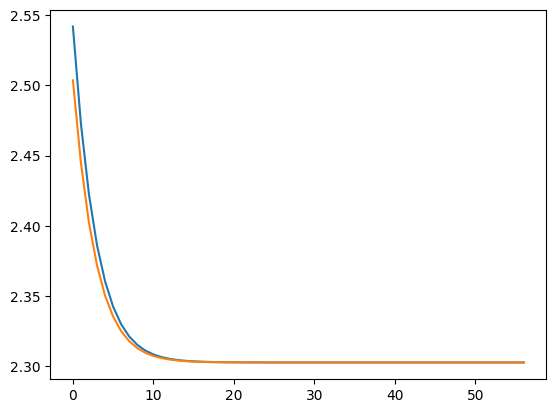

In [61]:
import matplotlib.pyplot as plt
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.show()

해당 이미지를 보면 빠른 수렴이 있으나 손실값이 2를 넘기는 것으로 봤을때 학습이 잘못된 상태임\
아래에선 배치정규화 진행

In [62]:
e_tr_x = tr_x.reshape(-1, 784) # 배치정규화 사용 위해 임치 처리
e_val_x = val_x.reshape(-1, 784) # 배치정규화 사용 위해 임치 처리

In [63]:
sgd = SGD(0.001)

In [64]:
m = Sequential()
m.add(Input(shape=tr_x.shape[1:]))
m.add(Flatten()) # 배치정규화 사용 위해 주석 처리
m.add(Dense(50, activation='sigmoid'))
m.add(BatchNormalization())
m.add(Dense(50, activation='sigmoid'))
m.add(BatchNormalization())
m.add(Dense(50, activation='sigmoid'))
m.add(BatchNormalization())
m.add(Dense(50, activation='sigmoid'))
m.add(BatchNormalization())
m.add(Dense(50, activation='sigmoid'))
m.add(BatchNormalization())
m.add(Dense(50, activation='sigmoid'))
m.add(BatchNormalization())
m.add(Dense(50, activation='sigmoid'))
# m.add(BatchNormalization())
m.add(Dense(10, activation='sigmoid'))
m.summary()
m.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['acc'])

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,260 (219.77 KB)

 Trainable params: 55,660 (217.42 KB)

 Non-trainable params: 600 (2.34 KB)

In [65]:
es = EarlyStopping(patience=10, restore_best_weights=False, verbose=1)
ck = ModelCheckpoint('bset_m.keras', save_best_only=True, verbose=1)

In [66]:
hy = m.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=100, callbacks=[es, ck])

Epoch 1/100
1299/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.2094 - loss: 2.1783
Epoch 1: val_loss improved from None to 1.74594, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.3322 - loss: 2.0108 - val_acc: 0.5563 - val_loss: 1.7459
Epoch 2/100
1298/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.5865 - loss: 1.6736
Epoch 2: val_loss improved from 1.74594 to 1.44065, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.6115 - loss: 1.5998 - val_acc: 0.6605 - val_loss: 1.4406
Epoch 3/100
1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6650 - loss: 1.4053
Epoch 3: val_loss improved from 1.44065 to 1.23219, saving model to bset_m.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.6738 - loss: 1.3534 - val_acc: 0.6935 - val_loss: 1.2322
Epoch 4/100
1294/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7019 - loss: 1.2164
Epoch 4: val_loss improved from 1.23219 to 1.08434, saving model to bset_m.keras
1313/1313 ━━━━━━

더 학습해야 할까? -> 학습 상태를 그래프로 보았을 때 결과에 따라 손실이 계속 줄고 정확도가 오르는 추세를 확인하고 ~할 것이다!라는 근거가 마련돼야 함(블랙박스 기법이라고 함)

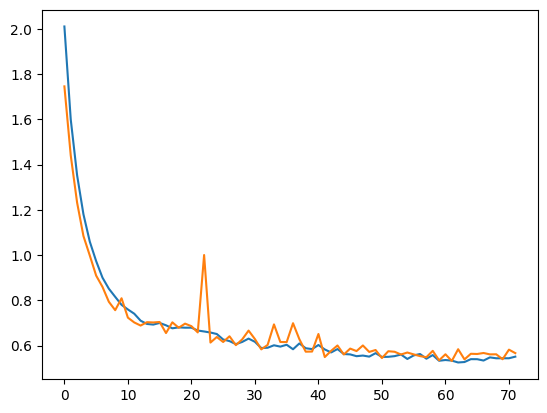

In [67]:
import matplotlib.pyplot as plt
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.show()

아래는 모델도 바꾸고 스케일링도 적용한 것

In [ ]:
m.fit(e_tr_x, tr_y, validation_data=(e_val_x, val_y), epochs=100, callbacks=[es, ck])

# 라이브러리 가져오기

In [160]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, LSTM, GRU, BatchNormalization, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error

패션 mnist를 이용하여 다중 분류기를 완성하시오
- 모델의 일반화 성능은 95점 이상
- 옵티마이저 자유
- 모델 구조 자유 (단 CNN 금지)
- 오전 11시 반까지 모델 결정 및 모델 저장파일 제출

# 데이터 로드

In [135]:
(x_data, y_data), (X_test, y_test) = fashion_mnist.load_data()
x_data.shape, y_data.shape

((60000, 28, 28), (60000,))

In [136]:
X_train, X_test, val_x, val_y = train_test_split(x_data, y_data, test_size=.25, stratify=y_data, random_state=42)

In [138]:
X_train.shape, X_test.shape, X_test.shape # 학습, 테스트, 검증

((45000, 28, 28), (15000, 28, 28), (15000, 28, 28))

# 모델 구조

In [145]:
m = Sequential()
m.add(Input(shape=(x_data.shape[1:])))
m.add(Flatten())
m.add(Dense(50, activation='relu'))
m.add(BatchNormalization())
m.add(Dense(50, activation='relu'))
m.add(BatchNormalization())
m.add(Dense(50, activation='relu'))
m.add(BatchNormalization())
m.add(Dense(50, activation='relu'))
m.add(BatchNormalization())
m.add(Dense(10, activation='softmax'))
m.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_27 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,210 (188.32 KB)

 Trainable params: 47,810 (186.76 KB)

 Non-trainable params: 400 (1.56 KB)

In [146]:
m.compile(optimizer=SGD(0.001), loss='sparse_categorical_crossentropy', metrics=['acc'])
# m.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['acc'])

In [147]:
es = EarlyStopping(patience=10, restore_best_weights=True)
ck = ModelCheckpoint('20250813.keras', save_best_only=True)

Epoch 1/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.6033 - loss: 1.2445 - val_acc: 0.7471 - val_loss: 0.8106
Epoch 2/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.7357 - loss: 0.8038 - val_acc: 0.7923 - val_loss: 0.6501
Epoch 3/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.7669 - loss: 0.6916 - val_acc: 0.8104 - val_loss: 0.6025
Epoch 4/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.7847 - loss: 0.6341 - val_acc: 0.8195 - val_loss: 0.5376
Epoch 5/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.7962 - loss: 0.5960 - val_acc: 0.8262 - val_loss: 0.5142
Epoch 6/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.8025 - loss: 0.5696 - val_acc: 0.8302 - val_loss: 0.4902
Epoch 7/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.8091 - loss: 0.5502 - val_acc: 0.8373 - val_loss: 0.4719
Epoch 8/200
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.8133 - loss: 0.5357 - val_acc: 0.8401 - val_loss: 0.4706
Epoch 9/200
1407/1407 ━━━━━━━━━━

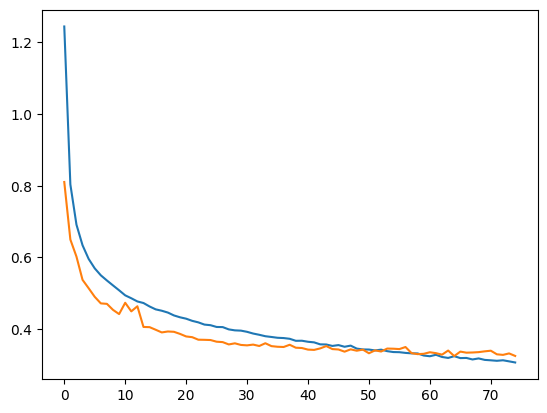

In [148]:
history = m.fit(X_train, val_x, validation_data=(X_test, val_y), epochs=200, callbacks=[es, ck])
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [149]:
m.evaluate(X_train, val_x)

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9058 - loss: 0.3192


[0.31924423575401306, 0.9058444499969482]

In [150]:
m.evaluate(X_test, val_y)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8861 - loss: 0.3249


[0.3249056339263916, 0.8861333131790161]

In [114]:
from keras.datasets import cifar10

In [157]:
(x_data, y_data), (tt_x, tt_y) = cifar10.load_data()

In [158]:
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, train_size=.8, stratify=y_data)
tr_x.shape, tr_y.shape, tt_x.shape, tt_y.shape, val_x.shape, val_y.shape

((40000, 32, 32, 3),
 (40000, 1),
 (10000, 32, 32, 3),
 (10000, 1),
 (10000, 32, 32, 3),
 (10000, 1))

In [129]:
m = Sequential()
m.add(Input(shape=tr_x.shape[1:]))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(100, activation='relu'))
m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))
m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [130]:
es = EarlyStopping(patience=10, restore_best_weights=True)
ck = ModelCheckpoint('best_m.keras', save_best_only=True)

In [131]:
hy = m.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=100, callbacks=[es, ck])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.1139 - loss: 6.3577 - val_acc: 0.1006 - val_loss: 2.3031
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.0962 - loss: 2.3025 - val_acc: 0.1002 - val_loss: 2.3024
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.0976 - loss: 2.3026 - val_acc: 0.1001 - val_loss: 2.3026
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.0974 - loss: 2.3029 - val_acc: 0.1001 - val_loss: 2.3026
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.0989 - loss: 2.3029 - val_acc: 0.0999 - val_loss: 2.3028
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.0972 - loss: 2.3028 - val_acc: 0.1001 - val_loss: 2.3024
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.0961 - loss: 2.3029 - val_acc: 0.1000 - val_loss: 2.3027
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.0979 - loss: 2.3028 - val_acc: 0.0999 - val_loss: 2.3027
Epoch 9/100
1250/1250 ━━━━━━━━━━

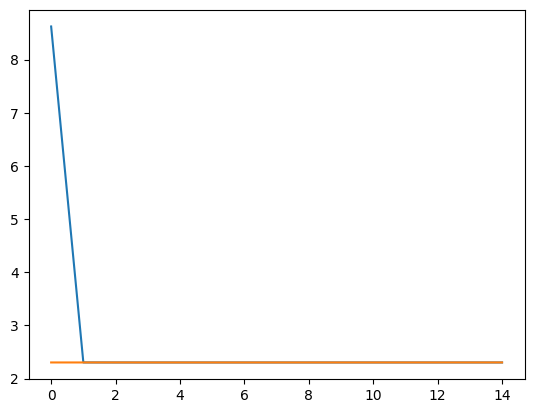

In [128]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.show()

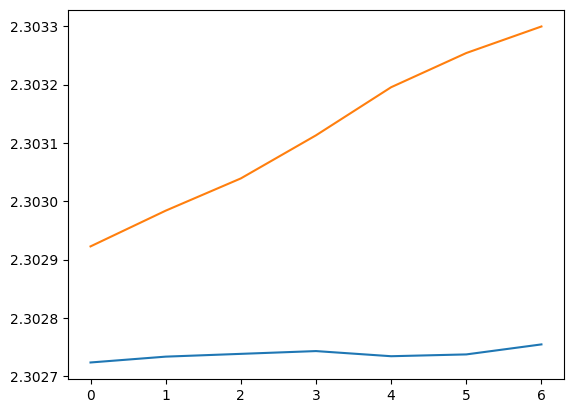

In [127]:
plt.plot(hy.history['loss'][8:])
plt.plot(hy.history['val_loss'][8:])
plt.show()

In [ ]:
# 위는 모델 구조가 input 784 -> dense 100 -> dense 10으로 한번에 줄어듦
# 정보가 빠르게 많은 양을 상실함
# 이번엔 더 많이 거쳐서 하도록 진행

----수업----

# CNN

In [151]:
# Conv2D() # 커널크기(이미지 수용 영역), 커널의 갯수(데이터를 바라보는 관점), 이동수(영역의 간격)
# MaxPool2D() # 연산감소 커널크기는 일반적으로 (2x2)권장
# # 입력 데이터(이미지(가로w,세로h,채널수c))

In [153]:
(_,_),(X,y) = fashion_mnist.load_data()
X.shape, y.shape # -> X를 이미지화를 해야됨

((10000, 28, 28), (10000,))

In [154]:
X.reshape(-1, 28,28,1).shape

(10000, 28, 28, 1)

In [159]:
tr_x.shape, tr_y.shape, tt_x.shape, tt_y.shape, val_x.shape, val_y.shape

((40000, 32, 32, 3),
 (40000, 1),
 (10000, 32, 32, 3),
 (10000, 1),
 (10000, 32, 32, 3),
 (10000, 1))

In [162]:
m = Sequential()
m.add(Input(shape=tr_x.shape[1:])) # 32,32,3
m.add(Conv2D(10,3,1, padding='same', activation='relu')) # 32,32,10
m.add(MaxPooling2D(2)) # 여기까지가 컨볼루션 레이어 한개를 설계한 것임
# maxpooling을 만나 16x16x10이 됨
m.add(Conv2D(10,3,1, padding='same', activation='relu')) # 16,16,10
m.add(MaxPooling2D(2)) # 8,8,10
m.add(Conv2D(10,3,1, padding='same', activation='relu')) # 8,8,10
m.add(MaxPooling2D(2)) # 4,4,10
m.add(Conv2D(10,3,1, padding='same', activation='relu')) # 4,4,10
m.add(MaxPooling2D(2)) # 2,2,10
m.add(Conv2D(10,3,1, padding='same', activation='relu')) # 2,2,10
m.add(MaxPooling2D(2)) # 1,1,10
m.add(Flatten()) # 벡터화
m.add(Dense(10, activation='softmax'))
m.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,030 (15.74 KB)

 Trainable params: 4,030 (15.74 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
from keras.metrics import Accuracy, F1Score
from sklearn.metrics import classification_report

In [164]:
acc = Accuracy(name='정확도')
f1 = F1Score()

In [165]:
m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=[acc, f1])

In [166]:
m.fit(tr_x, tr_y, epochs=10, )

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - f1_score: 0.1953 - loss: 2.0476 - 정확도: 0.0000e+00
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1955 - loss: 1.6928 - 정확도: 0.0000e+00
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1955 - loss: 1.5818 - 정확도: 0.0000e+00
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1955 - loss: 1.5085 - 정확도: 0.0000e+00
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1955 - loss: 1.4700 - 정확도: 0.0000e+00
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1956 - loss: 1.4259 - 정확도: 0.0000e+00
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1956 - loss: 1.3911 - 정확도: 0.0000e+00
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1956 - loss: 1.3607 - 정확도: 0.0000e+00
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - f1_score: 0.1956 - loss: 1.3370 - 정확도: 0.0000e+00
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s

In [167]:
# 0~255
s_tr_x = tr_x/255
s_tt_x = tt_x/255
s_val_x = val_x/255

In [176]:
m=Sequential()
m.add(Input(shape=tr_x.shape[1:]))#(32,32,3)
m.add(Conv2D(10,3,1,padding='same',activation='relu'))#(32,32,10)
m.add(MaxPooling2D(2))#(16,16,10)
m.add(Flatten())
m.add(Dense(10,activation='softmax'))
m.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [ ]:
hy = m.fit(s_tr_x, tr_y, validation_data=(s_val_x, val_y), epochs=10)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.4241 - loss: 1.6403 - val_acc: 0.5090 - val_loss: 1.4194
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.5234 - loss: 1.3584 - val_acc: 0.5383 - val_loss: 1.3293
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.5575 - loss: 1.2707 - val_acc: 0.5553 - val_loss: 1.2743
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.5774 - loss: 1.2161 - val_acc: 0.5720 - val_loss: 1.2391
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.5917 - loss: 1.1728 - val_acc: 0.5755 - val_loss: 1.2175
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.6043 - loss: 1.1386 - val_acc: 0.5757 - val_loss: 1.2255
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.6146 - loss: 1.1112 - val_acc: 0.5692 - val_loss: 1.2359
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.6219 - loss: 1.0847 - val_acc: 0.5917 - val_loss: 1.1932
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━

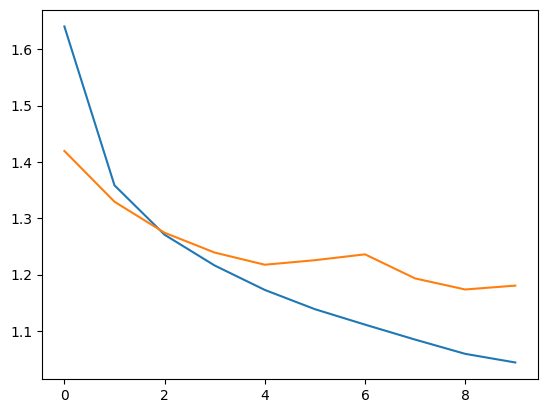

In [178]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

# cifar10을 만들기
- 1차: 이번엔 0.4 도달
- 2차: 금주까지 본인이 생각하기에는 최고인 모델을 완성하시오

In [185]:
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Conv2D, Dropout, MaxPooling2D, Flatten, ReLU
from keras.models import Sequential
from keras.losses import categorical_crossentropy, sparse_categorical_crossentropy
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping

In [180]:
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, train_size=.8, stratify=y_data)
tr_x.shape, tr_y.shape, tt_x.shape, tt_y.shape, val_x.shape, val_y.shape

((40000, 32, 32, 3),
 (40000, 1),
 (10000, 32, 32, 3),
 (10000, 1),
 (10000, 32, 32, 3),
 (10000, 1))

In [181]:
# 0~255
s_tr_x = tr_x/255
s_tt_x = tt_x/255
s_val_x = val_x/255

In [186]:
es = EarlyStopping(patience=5, restore_best_weights=True)
ck = ModelCheckpoint('202508_2week_homework.keras',save_best_only=True)

In [187]:
m=Sequential()
m.add(Input(shape=tr_x.shape[1:])) # (32,32,3)
m.add(Conv2D(20,3,1,padding='same',activation='relu') ) # (32,32,20)
m.add(MaxPooling2D(2))
m.add(Conv2D(20,3,1,padding='same',activation='relu') ) # (32,32,20)
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(10,activation='softmax'))
m.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])
m.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 20)     │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 20)     │         3,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,990 (66.37 KB)

 Trainable params: 16,990 (66.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
res = m.fit(s_tr_x, tr_y, epochs=100, validation_data=(s_val_x, val_y), callbacks=[es, ck])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.4426 - loss: 1.5600 - val_acc: 0.5276 - val_loss: 1.3424
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.5523 - loss: 1.2729 - val_acc: 0.5565 - val_loss: 1.2597
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - acc: 0.5900 - loss: 1.1690 - val_acc: 0.5735 - val_loss: 1.2082
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - acc: 0.6182 - loss: 1.0944 - val_acc: 0.6245 - val_loss: 1.0903
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.6364 - loss: 1.0423 - val_acc: 0.6259 - val_loss: 1.0844
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.6520 - loss: 1.0013 - val_acc: 0.6391 - val_loss: 1.0365
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.6648 - loss: 0.9653 - val_acc: 0.6416 - val_loss: 1.0422
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.6762 - loss: 0.9368 - val_acc: 0.6330 - val_loss: 1.0581
Epoch 9/100
1250/1250 ━━━━━━━━

# RNN 모델 학습 및 활용
- 텍스트 데이터 관점

In [ ]:
# steam 텍스트는 과제로 낼 거임

In [189]:
df = pd.read_csv('2025/Python/RNN_DATASET/data.csv')
df.head()

,name,genre,content
0,올드보이,스릴러,술 좋아하고 떠들기 좋아하는 오.대.수. 본인의 이름풀이를 오늘만 대충 수습하며 살...
1,노트북,로맨스,"17살, ‘노아’는 밝고 순수한 ‘앨리’를 보고 첫눈에 반한다. 빠른 속도로 서로에..."
2,미션임파서블,액션,"도난당한 핵무기를 되찾아 오는 위험천만한 작전 중, 에단 헌트(톰 크루즈)는 임무를..."
3,니모를찾아서,애니메이션,“디즈니`픽사 최고의 애니메이션이 3D로 다시 찾아온다!” 호기심 가득한 아기 물고...
4,탑건,액션,해군 최신 전투기 F-14기를 모는 젊은 조종사 매버릭 대위(톰 크루즈)는 최고의 ...


In [190]:
!pip install konlpy

   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ------------------ --------------------- 8.9/19.4 MB 47.3 MB/s eta 0:00:01
   ---------------------------- ----------- 13.6/19.4 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 19.4/19.4 MB 37.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 60.2 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [lxml]
   ------------- -------------------------- 1/3 [JPype1]
   -------------------------- ------------- 2/3 [konlpy]
   ---------------------------------------- 3/3 [konlpy]



In [202]:
df.head()

,name,genre,content
0,올드보이,스릴러,술 좋아하고 떠들기 좋아하는 오.대.수. 본인의 이름풀이를 오늘만 대충 수습하며 살...
1,노트북,로맨스,"17살, ‘노아’는 밝고 순수한 ‘앨리’를 보고 첫눈에 반한다. 빠른 속도로 서로에..."
2,미션임파서블,액션,"도난당한 핵무기를 되찾아 오는 위험천만한 작전 중, 에단 헌트(톰 크루즈)는 임무를..."
3,니모를찾아서,애니메이션,“디즈니`픽사 최고의 애니메이션이 3D로 다시 찾아온다!” 호기심 가득한 아기 물고...
4,탑건,액션,해군 최신 전투기 F-14기를 모는 젊은 조종사 매버릭 대위(톰 크루즈)는 최고의 ...


In [200]:
import codecs
with codecs.open('2025/Python/RNN_DATASET/steam.txt') as f:
    lines = [line for line in f.readlines()]

len(lines)

100000

In [ ]:
from konlpy.tag import Okt
from tqdm import tqdm
okt = Okt()
X_train = []
for sentence in tqdm(p_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True)
    X_train.append(tokenized_sentence)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
tk = Tokenizer(num_words=5000)
tk.fit_on_texts(X_train)

In [ ]:
X = tk.texts_to_matrix(X_train, mode='tfidf')

In [ ]:
Y_data = p_data['label']


# 딥러닝 시각모델